Generation 1: Best Neurons = 13, Fitness = 0.0063
Generation 2: Best Neurons = 15, Fitness = 0.0021
Generation 3: Best Neurons = 15, Fitness = 0.0021
Generation 4: Best Neurons = 15, Fitness = 0.0021
Generation 5: Best Neurons = 15, Fitness = 0.0021
Generation 6: Best Neurons = 15, Fitness = 0.0021
Generation 7: Best Neurons = 15, Fitness = 0.0021
Generation 8: Best Neurons = 15, Fitness = 0.0021
Generation 9: Best Neurons = 15, Fitness = 0.0021
Generation 10: Best Neurons = 15, Fitness = 0.0021
Generation 11: Best Neurons = 15, Fitness = 0.0021
Generation 12: Best Neurons = 15, Fitness = 0.0021
Generation 13: Best Neurons = 15, Fitness = 0.0021
Generation 14: Best Neurons = 15, Fitness = 0.0021
Generation 15: Best Neurons = 15, Fitness = 0.0021
Generation 16: Best Neurons = 15, Fitness = 0.0021
Generation 17: Best Neurons = 15, Fitness = 0.0021
Generation 18: Best Neurons = 15, Fitness = 0.0021
Generation 19: Best Neurons = 15, Fitness = 0.0021
Generation 20: Best Neurons = 15, Fitnes

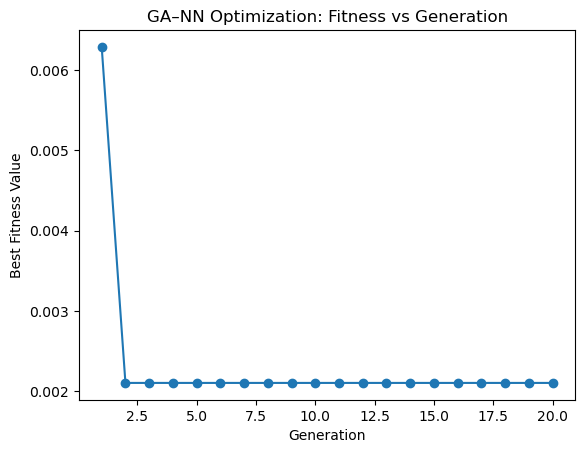


Final Optimized Result
Optimal Hidden Neurons: 13
Best Fitness Value: 0.0063


In [1]:
# -------------------------------
# Imports
# -------------------------------
import numpy as np
import random
import matplotlib.pyplot as plt

from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

# -------------------------------
# Data Generation
# -------------------------------
np.random.seed(42)

X = np.random.rand(100, 3)
X[:, 0] *= 200      # Inlet temperature
X[:, 1] *= 50       # Feed rate
X[:, 2] *= 30000    # Atomization speed

y = 0.3*X[:,0] - 0.02*X[:,1] + 0.0001*X[:,2] + np.random.randn(100)*5

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1
)

# -------------------------------
# Fitness Function
# -------------------------------
def fitness_function(hidden_neurons):
    model = MLPRegressor(
        hidden_layer_sizes=(hidden_neurons,),
        max_iter=500,
        random_state=1
    )
    
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    
    mse = mean_squared_error(y_test, predictions)
    return 1 / (1 + mse)

# -------------------------------
# Selection
# -------------------------------
def selection(population, fitness_scores):
    selected = []
    pop_size = len(population)

    for _ in range(pop_size):
        i = random.randint(0, pop_size - 1)
        j = random.randint(0, pop_size - 1)

        if fitness_scores[i] > fitness_scores[j]:
            selected.append(population[i])
        else:
            selected.append(population[j])

    return selected

# -------------------------------
# Crossover
# -------------------------------
def crossover(parents, crossover_rate):
    offspring = []

    for i in range(0, len(parents), 2):
        if i + 1 < len(parents) and random.random() < crossover_rate:
            child = (parents[i] + parents[i + 1]) // 2
        else:
            child = parents[i]

        offspring.append(child)

    return offspring

# -------------------------------
# Mutation
# -------------------------------
def mutation(offspring, mutation_rate):
    for i in range(len(offspring)):
        if random.random() < mutation_rate:
            offspring[i] += random.randint(-2, 2)
            offspring[i] = max(1, offspring[i])

    return offspring

# -------------------------------
# GA Parameters
# -------------------------------
population_size = 10
generations = 20
crossover_rate = 0.85
mutation_rate = 0.05

population = [random.randint(5, 20) for _ in range(population_size)]

best_fitness_history = []
best_solution = None
best_fitness = 0

# -------------------------------
# GA Loop
# -------------------------------
for gen in range(generations):

    fitness_scores = [fitness_function(ind) for ind in population]

    current_best = max(fitness_scores)
    current_solution = population[fitness_scores.index(current_best)]

    best_fitness_history.append(current_best)

    if current_best > best_fitness:
        best_fitness = current_best
        best_solution = current_solution

    print(f"Generation {gen+1}: Best Neurons = {current_solution}, Fitness = {current_best:.4f}")

    selected = selection(population, fitness_scores)
    offspring = crossover(selected, crossover_rate)
    population = mutation(offspring, mutation_rate)

# -------------------------------
# Plot Graph
# -------------------------------
plt.figure()
plt.plot(range(1, generations + 1), best_fitness_history, marker='o')
plt.xlabel("Generation")
plt.ylabel("Best Fitness Value")
plt.title("GA–NN Optimization: Fitness vs Generation")
plt.show()

# -------------------------------
# Final Output
# -------------------------------
print("\nFinal Optimized Result")
print("Optimal Hidden Neurons:", best_solution)
print("Best Fitness Value:", round(best_fitness, 4))